PHY 411 Final Project: self-consistent Schrödinger Poisson solver for a 1D semiconductor quantum well heterostructure

Physics background

When two semiconductor materials with different bandgaps are layered in an alternating way, the material with the smaller bandgap forms a quantum well which confines charge carriers in the valence and conduction bands. This is because holes in the valence band will seek to occupy the highest energy levels and electrons in the conduction band will seek to occupy the lowest energy levels hence making them confined in the layers with smaller bandgaps. The bound states of these quantum wells are what determine the electrical and optical properties of the heterostructure. To find those bound states two equations need to be solved for: Schrödinger’s equation and Poisson’s equation. Schrödinger’s equation gives the quantized energy levels and wavefunctions for a given potential. Poisson’s equation gives the electrostatic potential produced by the charge distribution that the electrons create themselves. These two equations are coupled in a heterostructure because Schrödinger’s equation needs the potential to find the wavefunction and Poisson’s equation needs the wavefunction to find the charge density and in turn find the electrostatic potential.

Material choice

The materials I chose for this simulation to make up the semiconductor layers are GaAs and AlGaAs. That is gallium arsenide and aluminum gallium arsenide and there are three main reasons i chose these materials. The first reason is the most technical one, the materials have a very well documented electron mass, conduction and valence band offsets, and dielectric constant which are all important variables to know for the simulation to occur. The second reason is that I am familiar with this type of heterostructure a bit more then any other as I performed an reflectance spectroscopy experiment on this exact type of semiconductor heterostructure in my advanced physics lab, and am using this project to both expand on that experiment as well as try to learn new things in this subfield of physics. The final reason I chose these two materials specifically was that I wanted to choose materials which realistically could exist and GaAs and AlGaAs have closely matching lattice constants which allows for easy epitaxial growth. So the final heterostructure will consist of alternating layers of gallium arsenide and aluminum gallium arsenide, with the AlGaAs layers being the barrier layers. I have listed below the molecular formula for AlGaAs:

$
Al_{\chi}Ga_{1-\chi}As
$

The chi in this formula represents the aluminum concentration in the material, as aluminum gallium arsenide is a alloy consisting of gallium arsenide and aluminum arsenide. This is important because both the conduction and valence band offsets which make up the potential barriers in the quantum well have a dependence on this variable

$
\Delta E_c = 0.80 \chi
$

$
\Delta E_v = 0.51 \chi
$

Finally, a few notes on the simulation itself as well as its limitations. First, for this model only the conduction band will be simulated. This was a purely logistical choice to simplify the model and make it easier to program. If I were to repeat this project in the future, Programming both should not be an issue as the charge density in the conduction band should not affect the electrostatic potential in the valence band and vice versa. Additionally only a few constants would need to be switched such as using light and heavy holes instead of electrons (The valence band is two fold degenerate) meaning the electron mass and charge should be different. This should create the opposite effect of what we see in the consistency loop shown later due to the opposite charge of the holes. Limitations of the models include the following: position dependant mass was not accounted for and all subbands were equally occupied, ignoring fermi dirac statistics. No position dependant mass was purely a choice to make the programming easier and did not make a significant impact on the physical reliability of the model as far as I believe. Ignoring the fermi dirac statistics as a more egregious error on my part as it did not occur to me that the physical outcome of the model would be far from realistic if all bound states were to be considered equally occupied, as the probability distribution of the electrons and the charge would be inconsistent. 


Motivation

The reason a model like this is worth building goes beyond the physics of an isolated quantum well. The channel of a modern MOSFET (metal oxide semiconductor field effect transistor) is itself a nanometer scale quantum well, and the behaviour of that channel is what determines how the transistor turns on, how much current it carries, and how much power it dissipates. There are more MOSFETs in existence than grains of sand on earth and they sit inside essentially every piece of modern electronics, so understanding how the subband energies and charge distribution inside a thin well behave under self consistency is directly relevant to device design. Industry standard TCAD (technology computer aided design) tools such as Sentaurus and Silvaco all include self consistent Schrödinger Poisson solvers for exactly this reason. The solver built in this notebook is a much simpler version of the same idea, and it captures the key physics that those commercial tools also capture: the electrons in the well rearrange the potential they themselves move in, and the energy levels are not the ones you would naively read off a bare square well.

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import math

before any calculations can be made, a few constants and physical parameters need to be established. These include the regular and reduced plancks constant, the charge of an electron, the mass of an electron, the effective mass of an electron in the semiconductor material I chose, the permittivity inside the semiconductor, the potential of the quantum well (conduction band offset converted into joules), and the sheet density of electrons inside the structure. 

In [3]:
h = 6.62e-34
hbar = h/(2*math.pi)
q = 1.602e-19
m0 = 9.11e-31
eps0 = 8.85e-12
m_eff = 0.067 * m0
eps_r = 12.9
eps = eps_r * eps0
V0 = 0.228 * q
n_s = 2e15

Domain setup and Discretization

The doimain consists of a GaAs quantum well layer with a width of 10 nanometers in between two AlGaAs barrier layers with widths of 30 nanometers. The total length of the domain is set to 70 nanometers and is discretized into a uniform grid of 1000 points with each point being about 0.07 nanometers large. 

In [4]:
Lw = 10e-9
Lb = 30e-9
L = 2*Lb + Lw
N = 1000
z = np.linspace(0, L, N)
dz = z[1]-z[0]

This portion of the code builds the potential in the profile of the conduction band. It starts by establishing that the well begins at the index in the domain where the first barrier layer ends and ends at the index in the domain where the second barrier layer starts. After this it enforces a constant potential outlined in the physical parameters section in between those two indexes, Creating a bare conduction band edge. 

In [5]:
i_start = int(Lb / dz)
i_end   = int((Lb + Lw) / dz)
Vband   = np.full(N, V0)
Vband[i_start:i_end] = 0.0


The next three functions are all helper functions created to help with solving Schrödinger’s and Poisson’s equations. The basic idea behind all three is the same, solve Schrödinger’s/Poisson’s equation using the finite-difference formula to convert Schrödinger and Poisson’s equations into discrete linear algebra matrices that can be solved using NumPy


The reason Schrödinger’s and Poisson’s equations cant be solved directly is because computers cant solve continous differential equations and instead need them to be converted into discrete matrix eigenvalue problems to solve. This is what the central difference formula does for the second derivates in both equations

Schrödinger’s equation:

$$
-\frac{\hbar^2}{2m^\ast}\frac{d^2\psi}{dz^2} + V(z)\,\psi = E\,\psi.
$$

Poisson’s equation:

$$
\frac{d^2\phi}{dz^2} = -\frac{\rho(z)}{\varepsilon}.
$$

The central finite difference formula applied to the second derivative in the Schrödinger equation is provided as an example. 

$$
\left.\frac{d^2\psi}{dz^2}\right|_{z_i} \approx \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{dz^2}.
$$

Using the existing domain and the formula above, Schrödinger’s equation becomes a hamiltonian equation

$
\hat{H} \psi = E \psi
$

where $\hat{H}$ is a tridiagonal matrix with the main diagonal holding the kinetic energy as well as the local potential at each grid point and the off diagonals holding the coupling between neighboring grid points, each given by main and off in the hamiltonian helper function. Once the hamiltonian is built, NumPy.linalg.eigh is used to diagonalize it and return corresponding eigenvalues and eigenvectors. 

$$\hat{H}\,\boldsymbol{\psi}_n = E_n\,\boldsymbol{\psi}_n.$$

As a rule, each eigenvector corresponding to the wavefunction of a bound state is normalized on the discrete grid using the following formula

$\sum_i |\psi_{n,i}|^2\,dz = 1$

Additionally, only eigenvalues corresponding to energy states below the potential barrier are considered and everything else is discarded because bound states are the only states we need. 

For Poisson’s equation:

$$\frac{d^2\phi}{dz^2} = -\frac{\rho(z)}{\varepsilon},$$

The equation is discretised with the same central finite difference formula and the following linear system is the result

$$\hat{A}\,\boldsymbol{\phi} = -\boldsymbol{\rho}/\varepsilon,$$

which is a tridiagonal Laplacian matrix with $-2/dz^2$ being the main diagonal and $1/dz^2$ being the off diagonals. For this matrix dirichlet conditions are explicitly created such that the first and last rows of A are set to identity rows and making their corresponding entries on the right hand side zero to enforce $\phi(0)$ and $\phi(L)$ = 0. Once this is done numpy.linalg.solve is used to solve the linear system and return $\phi(z)$ on the grid. 

In [6]:
def build_H(V):
    coeff = hbar**2 / (2 * m_eff * dz**2)
    main  = 2*coeff + V
    off   = -coeff * np.ones(N-1)
    return np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

In [7]:
def solve_schrodinger(V):
    E_vals, psi = np.linalg.eigh(build_H(V))
    for n in range(psi.shape[1]):
        norm = np.sqrt(np.sum(psi[:,n]**2) * dz)
        psi[:,n] /= norm
    bound = E_vals < V0
    return E_vals[bound], psi[:, bound]


In [8]:
def solve_poisson(rho):
    # Poisson equation: ∇²φ = -ρ/ε
    main = -2 * np.ones(N) / dz**2
    off  =  np.ones(N-1)  / dz**2
    A    = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)
    b    = -rho / eps
    A[0,:]  = 0; A[0,0]   = 1; b[0]  = 0
    A[-1,:] = 0; A[-1,-1] = 1; b[-1] = 0
    return np.linalg.solve(A, b)

Before the model is simulated with the self consistency loop, the bare conduction band profile was plotted to confirm the geometry is correct. The expected shape is a square quantum well with a $\approx$ 228 meV potential offset centered in between the positions 30 and 40 nanometers.

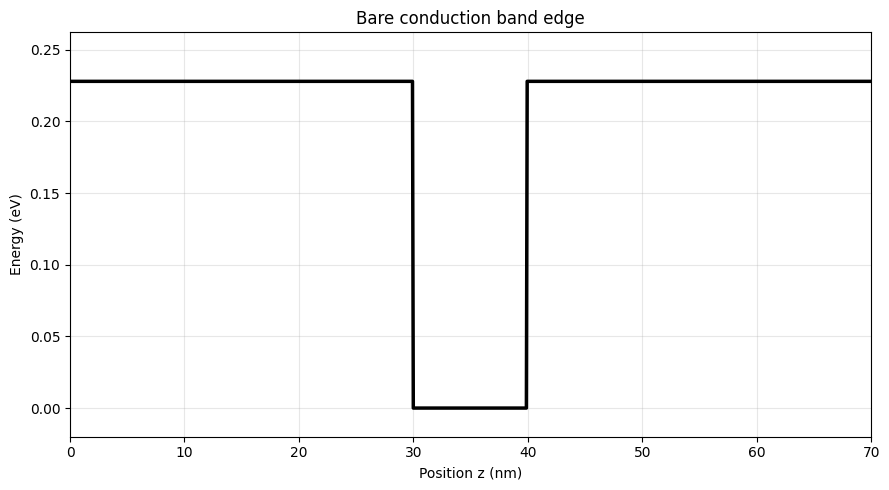

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z*1e9, Vband/q, color='black', lw=2.5)
ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Bare conduction band edge')
ax.set_xlim(0, L*1e9)
ax.set_ylim(-0.02, V0/q * 1.15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

To ensure the accuracy of the model, I compared the solutions from my method of solving Schrödinger’s equation with an infinite square well approximation. This is because the infinite square well has a known closed-form answer, given by the following equation:

$$
E_n = \frac{n^2 \pi^2 \hbar^2}{2 m^\ast L_{\text{eff}}^2}.
$$

Where the energy states depend entirely on the effective width of the well. To solve for this the hamiltonian was restricted to just the grid points in the domain inside the well, simulating and infinite well barrier. The effective width used in the analytical formula is $L_{\text{eff}} = (N_{\text{well}} + 1)\,dz$ because the wavefunction nodes sit one grid spacing past each end of the matrix. For clarification, when referring to energy states solved using the infinite well approximation, I call it the analytical method and when referring to the energy states and wavefunctions solved using the diagonalization method I call it the numerical method. 

The first four numerical eigenvalues corresponding to energy states of the infinite well approximation and the solver were compared and printed in a bar chart with the percent error between each labeled on top of each energy state. The agreement between numerical and analytical methods confirm that the discretisation was done correctly. Additionally, the first four energy states solved using the numerical and analytical methods in electron volts and the percent difference between them is provided in a chart.


  n  Numerical (eV)   Analytical (eV)    % error
  1         0.05580           0.05580     0.0040
  2         0.22316           0.22320     0.0161
  3         0.50202           0.50220     0.0362
  4         0.89222           0.89280     0.0643


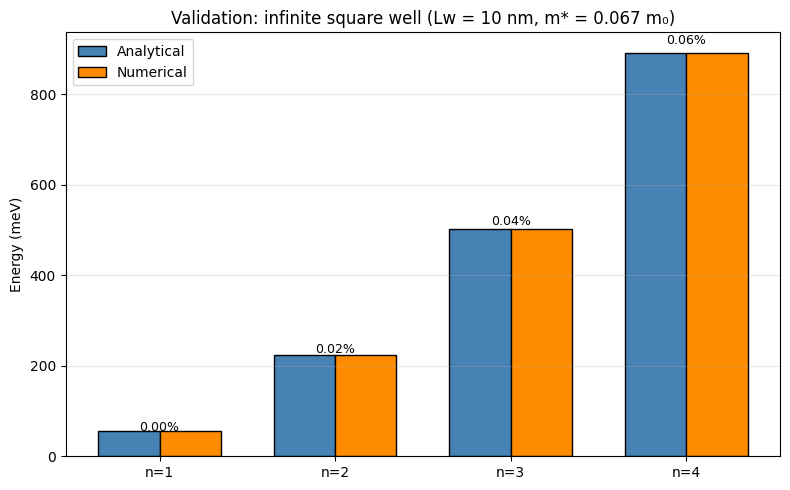

In [10]:
N_well  = i_end - i_start
coeff_w = hbar**2 / (2 * m_eff * dz**2)
main_w  = 2 * coeff_w * np.ones(N_well)
off_w   = -coeff_w * np.ones(N_well - 1)
H_inf   = np.diag(main_w) + np.diag(off_w, 1) + np.diag(off_w, -1)
E_num_all, psi_inf_all = np.linalg.eigh(H_inf)
E_num    = E_num_all[:4]
psi_inf  = psi_inf_all[:, :4]

# Normalize the infinite-well wavefunctions
for n in range(psi_inf.shape[1]):
    norm = np.sqrt(np.sum(psi_inf[:, n]**2) * dz)
    psi_inf[:, n] /= norm

# Analytical infinite well: E_n = n^2 pi^2 hbar^2 / (2 m* L_eff^2)
# Effective width = (N_well + 1)*dz because psi=0 at the implicit nodes
# just outside the matrix means the wavefunction vanishes at z=0 and z=L_eff.
L_eff = (N_well + 1) * dz
n_levels = np.arange(1, 5)
E_analytic = (n_levels**2 * np.pi**2 * hbar**2) / (2 * m_eff * L_eff**2)

# Print comparison table
print(f"{'n':>3} {'Numerical (eV)':>15} {'Analytical (eV)':>17} {'% error':>10}")
for i in range(4):
    err = 100 * abs(E_num[i] - E_analytic[i]) / E_analytic[i]
    print(f"{i+1:>3} {E_num[i]/q:>15.5f} {E_analytic[i]/q:>17.5f} {err:>10.4f}")

# Plot 1: bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(4)
width = 0.35
ax.bar(x_pos - width/2, E_analytic/q*1000, width, label='Analytical',
       color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, E_num/q*1000, width, label='Numerical',
       color='darkorange', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'n={n}' for n in n_levels])
ax.set_ylabel('Energy (meV)')
ax.set_title(f'Validation: infinite square well (Lw = {Lw*1e9:.0f} nm, m* = 0.067 m₀)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add % error labels above bars
for i in range(4):
    err = 100 * abs(E_num[i] - E_analytic[i]) / E_analytic[i]
    ax.text(i, max(E_num[i], E_analytic[i])/q*1000 * 1.02,
            f'{err:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

This portion of the code plots the infinite well approximation with the first four numerical wavefunctions included as well as the analytical energy levels drawn as dotted lines. The numerical wavefunctions sit on top of the analytical lines, providing additional proof that the numerical and analytical methods agree.

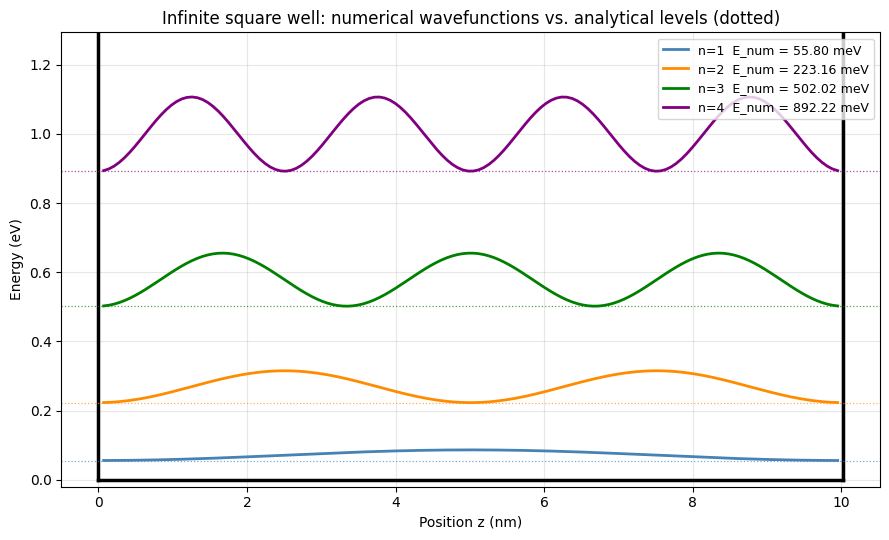

In [11]:
z_well = np.linspace(dz, N_well * dz, N_well)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Draw the infinite-well "potential": V=0 inside, vertical walls at edges
wall_height = E_num[3] / q * 1.45
ax.plot([0, 0],                 [0, wall_height], color='black', lw=2.5)
ax.plot([L_eff*1e9, L_eff*1e9], [0, wall_height], color='black', lw=2.5)
ax.plot([0, L_eff*1e9],         [0, 0],           color='black', lw=2.5)

colors = ['steelblue', 'darkorange', 'green', 'purple']
# Scale each wavefunction relative to spacing so node structure is visible
spacings = np.diff(np.concatenate(([0.0], E_num/q, [wall_height])))
scales   = 0.55 * np.minimum(spacings[:-1], spacings[1:])

for n in range(4):
    psi2      = psi_inf[:, n]**2
    psi2_norm = psi2 / psi2.max()
    wf_plot   = scales[n] * psi2_norm + E_num[n]/q
    ax.plot(z_well*1e9, wf_plot, color=colors[n], lw=2,
            label=f'n={n+1}  E_num = {E_num[n]/q*1000:.2f} meV')
    # Dotted analytical level for comparison
    ax.axhline(E_analytic[n]/q, color=colors[n], lw=0.9, ls=':', alpha=0.7)

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Infinite square well: numerical wavefunctions vs. analytical levels (dotted)')
ax.set_xlim(-0.5, L_eff*1e9 + 0.5)
ax.set_ylim(-0.02, wall_height)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now that the accuracy of the numerical methods is validated, the self consistency loop can be created. The loop uses the full finite domain with the barrier layers included. The parameters of the loop are as follows

Alpha = 0.2

tolerance = 1e-6 * q

max_iter = 200

alpha is the damping parameter and is used to create a weighted average of the old potential compared to the new potential so that one iteration doesnt overshoot and skew the results for the next iterations. the formula this follows is as follows 

$$V_{\text{next}} = \alpha\,V_{\text{new}} + (1 - \alpha)\,V_{\text{old}}.$$

The tolerance is the criteria for convergence. The loop stops iterating when the maximum difference in potentials between subsequent iterations is less then the tolerance which is set at one micro electron volt

max_iter is a hard cap on iterations set as a safety net

The loop also solves Schrödinger’s equation once with the bare conduction band edge as the potential and stores the result so that it can be compared against the final converged potential. 

In [12]:
alpha     = 0.2
tolerance = 1e-6 * q
max_iter  = 200

# ─── Solve bare Schrödinger first (no charge) and save for later plot ─────
E_bare, psi_bare = solve_schrodinger(Vband)
E_bare   = E_bare[:3]
psi_bare = psi_bare[:, :3]

print(f"\nBare-well bound state energies (no self-consistency):")
for i, e in enumerate(E_bare):
    print(f"  E{i} = {e/q:.4f} eV")


Bare-well bound state energies (no self-consistency):
  E0 = 0.0322 eV
  E1 = 0.1230 eV


The bare well bound states are plotted here with their wavefunctions as a starting point for the self-consistent loop. The two bound states which appear for this well have approximately the following energies

- $E_0 \approx 32$ meV
- $E_1 \approx 123$ meV

The wavefunctions decay visibly and exponentially into the barrier layers which is standard for finite well behaviour

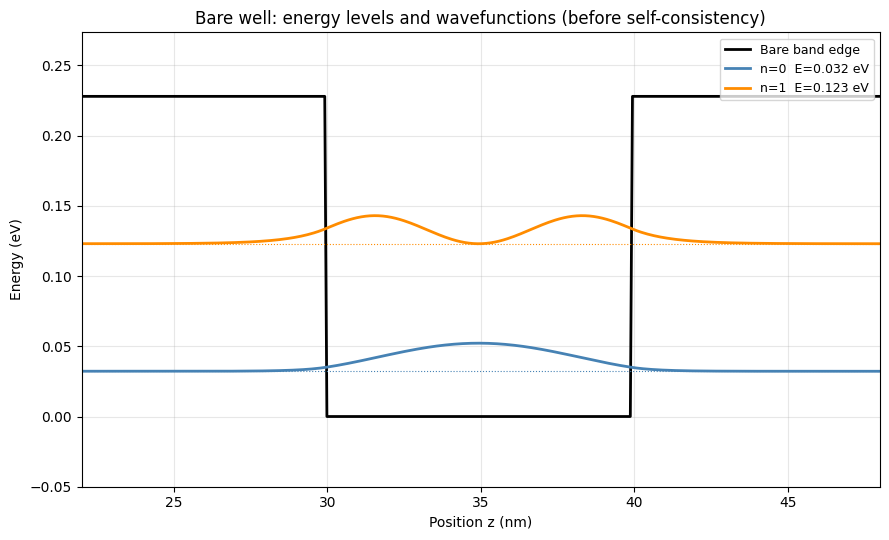

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(z*1e9, Vband/q, color='black', lw=2, label='Bare band edge')

colors = ['steelblue', 'darkorange', 'green']
scale  = 0.02
for n in range(len(E_bare)):
    psi2      = psi_bare[:, n]**2
    psi2_norm = psi2 / psi2.max()
    wf_plot   = scale * psi2_norm + E_bare[n]/q
    ax.plot(z*1e9, wf_plot, color=colors[n], lw=2,
            label=f'n={n}  E={E_bare[n]/q:.3f} eV')
    ax.axhline(E_bare[n]/q, color=colors[n], lw=0.8, ls=':')

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Bare well: energy levels and wavefunctions (before self-consistency)')
ax.set_xlim((Lb - 8e-9)*1e9, (Lb + Lw + 8e-9)*1e9)
ax.set_ylim(-0.05, V0/q * 1.20)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The self consistency loop itself is the main bulk of the computational portion of this project and the process it follows is outlined here. The following steps are followed until convergence occurs

1. Solve Schrödinger on the current potential $V_{\text{old}}$ → get $E_n$ and $\psi_n$.
2. Build the electron density from the bound-state wavefunctions:
   $$ n(z) = \sum_n |\psi_n(z)|^2, $$
   then normalise so that $\int n(z)\,dz = 1$, multiply by the sheet density $n_s$, and convert to a charge density $\rho(z) = -q\,n_s\,n(z)$.
   *(Note A fully realistic treatment would weight them by Fermi–Dirac occupation, outlined in the Limitations section.)*
3. Solve Poisson to get the electrostatic potential $\phi(z)$ generated by that charge density.
4. Update the potential: $V_{\text{new}} = V_{\text{band}} - q\,\phi$.
5. Mix with damping: $V_{\text{next}} = \alpha V_{\text{new}} + (1-\alpha) V_{\text{old}}$.
6. Check convergence: stop if $\max_z |V_{\text{next}} - V_{\text{old}}| < 1\,\mu\text{eV}$, otherwise repeat.

The reason this loop has to exist at all is that the two equations are coupled in a circular way. Schrödinger's equation needs the potential $V(z)$ as an input to give back the wavefunctions and energies, but the potential itself depends on where the electrons end up, which is exactly what the wavefunctions tell you through the charge density. So Poisson's equation needs the wavefunctions to give back the potential. Neither equation can be solved on its own, you need both, and the only way to get a potential that is consistent with the wavefunctions it produces is to alternate between them until they stop changing. This is what self consistency means in this context. The damping factor $\alpha$ is there because if the potential update at each step were applied fully, the solver would tend to overshoot the correct answer and oscillate back and forth instead of settling. Mixing the new potential with the old one slows the update down and lets the solution approach the fixed point smoothly, which is what produces the clean exponential convergence seen later in the convergence plot.

In [14]:
V_old = Vband.copy()
history = []

for iteration in range(max_iter):
    E, psi = solve_schrodinger(V_old)
    E   = E[:3]
    psi = psi[:, :3]

    # Electron density (assuming all bound subbands occupied equally — limitation)
    n_z = np.sum(psi**2, axis=1)
    n_z = n_z / (np.sum(n_z) * dz)
    rho = -q * n_s * n_z

    phi   = solve_poisson(rho)
    V_new = Vband - q * phi

    V_next = alpha * V_new + (1 - alpha) * V_old
    diff   = np.max(np.abs(V_next - V_old))
    history.append(diff / q * 1000)   # store in meV

    if diff < tolerance:
        print(f"Converged in {iteration+1} iterations.")
        break
    V_old = V_next

V_final = V_next
n_final = n_s * n_z   # final electron density (1/m³)

print(f"\nBound state energies:")
for i, e in enumerate(E):
    print(f"  E{i} = {e/q:.4f} eV")

Converged in 42 iterations.

Bound state energies:
  E0 = 0.0766 eV
  E1 = 0.1662 eV


The results of the self consistency loop is plotted below. The plot overlays the bare band edge with the self consistent band edge as well as the bound state wavefunctions at their energies after convergence. The two main effects which are visible are that

The bound state energies shift upwards approximately 43 to 45 milli electron volts

The bottom of the well along with the band edge in the well is no longer flat. The negative charge of the electrons created an electrostatic potential which pushes the edge up in the center

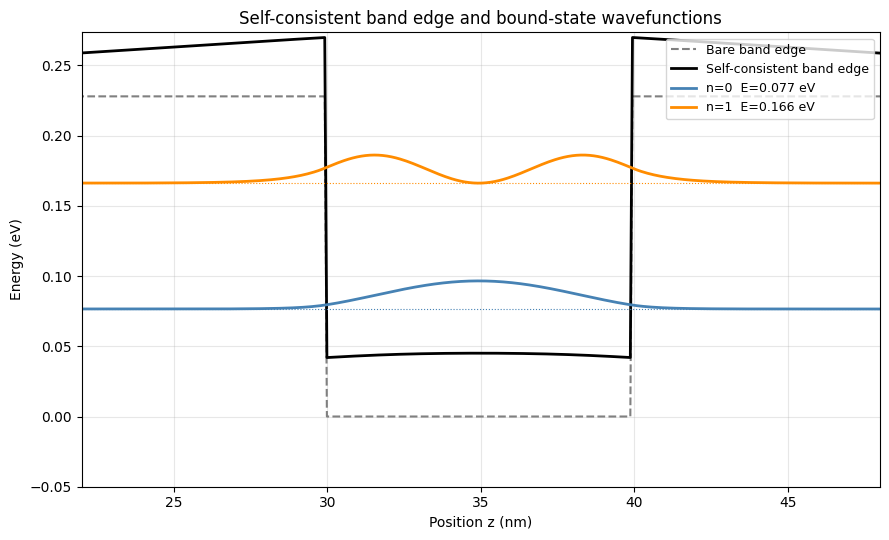

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(z*1e9, Vband/q,   color='gray',  lw=1.5, ls='--', label='Bare band edge')
ax.plot(z*1e9, V_final/q, color='black', lw=2,           label='Self-consistent band edge')

colors = ['steelblue', 'darkorange', 'green']
scale  = 0.02
for n in range(len(E)):
    psi2      = psi[:,n]**2
    psi2_norm = psi2 / psi2.max()
    wf_plot   = scale * psi2_norm + E[n]/q
    ax.plot(z*1e9, wf_plot, color=colors[n], lw=2,
            label=f'n={n}  E={E[n]/q:.3f} eV')
    ax.axhline(E[n]/q, color=colors[n], lw=0.8, ls=':')

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Self-consistent band edge and bound-state wavefunctions')
ax.set_xlim((Lb - 8e-9)*1e9, (Lb + Lw + 8e-9)*1e9)
ax.set_ylim(-0.05, V0/q * 1.20)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The physical reason this upward shift occurs is electron electron repulsion. In the bare well calculation, the electrons feel only the conduction band offset created by the heterostructure and nothing else. Once the self consistency loop is turned on, the negative charge density of the electrons in the well creates its own electrostatic potential through Poisson's equation, and because the electrons all carry the same sign of charge, that potential pushes the band edge upward in the region where the electrons are concentrated. The well is no longer a flat bottomed square, it now has a slight upward bulge in the middle that reflects the charge sitting there. The bound states are solved on this new modified potential and end up at higher energies than they would in the bare well, which is what shows up as the roughly 45 meV upward shift for both subbands. The fact that both states shift by almost the same amount is a sign that the electrostatic correction is acting more or less uniformly across the well rather than affecting one subband much more than the other.

To better explain the physical phenomena occurring in the quantum well after the self consistency loop, The electron density needs to be analyzed. The electron density profile after convergence is plotted and two main features are prominent

The electron density has two peaks at around 1/4 and 3/4 of the well

This is where the limitation of the fermi dirac statistics not being taken into account comes in. Since the wavefunctions of both bound states are being weighted equally, the resulting profile occurs. if fermi dirac statistics were to be taken into account, the first bound state would have higher precedence and the profile would have more of a single hump in the middle.

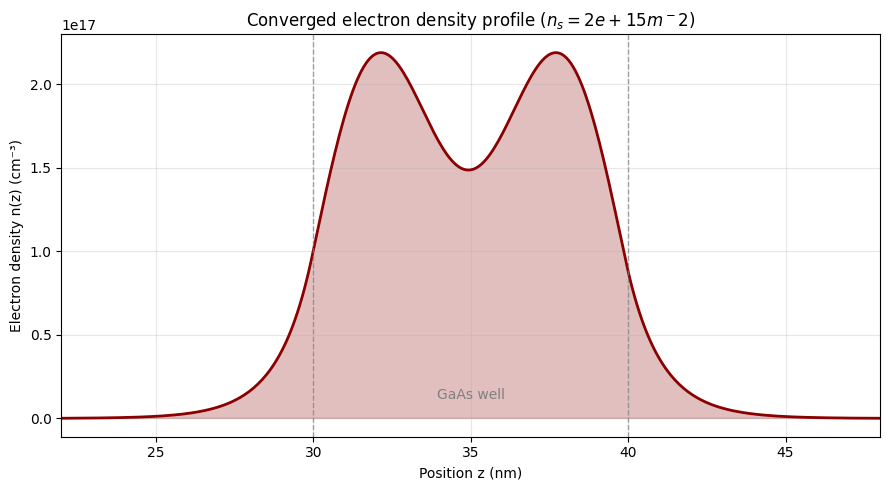

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
# Convert volumetric density (1/m³) to a more readable unit (1/cm³)
ax.plot(z*1e9, n_final/1e6, color='darkred', lw=2)
ax.fill_between(z*1e9, n_final/1e6, alpha=0.25, color='darkred')

# Mark well boundaries
ax.axvline(Lb*1e9,         color='gray', ls='--', lw=1, alpha=0.7)
ax.axvline((Lb + Lw)*1e9,  color='gray', ls='--', lw=1, alpha=0.7)
ax.text(Lb*1e9 + Lw*1e9/2, ax.get_ylim()[1]*0.05,
        'GaAs well', ha='center', fontsize=10, color='gray')

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Electron density n(z) (cm⁻³)')
ax.set_title(f'Converged electron density profile ($n_s = {n_s:.0e} m^{-2}$)')
ax.set_xlim((Lb - 8e-9)*1e9, (Lb + Lw + 8e-9)*1e9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This final plot displays the max number of potential differences as a function of iteration number to show how the convergence of the self-consistency loop occurs exponentially in around 42 iterations. The plot is straight on a log scale, which means an exponential decrease is occurring. The tolerance before iteration ends is added as a red dashed line.

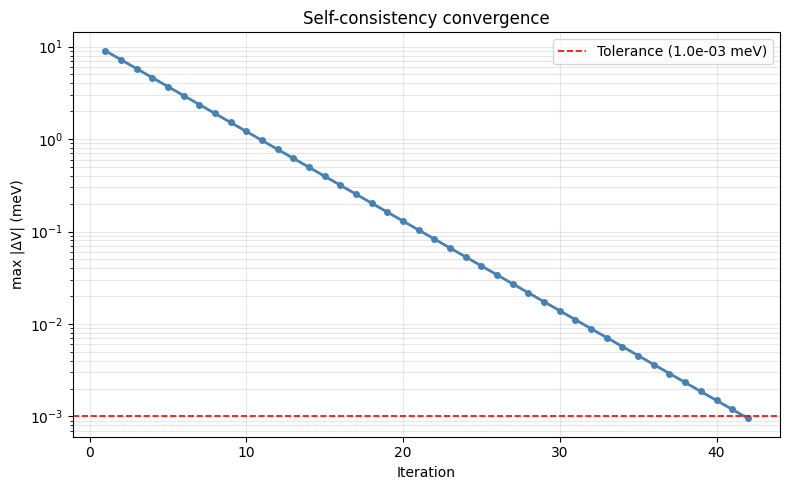

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(np.arange(1, len(history)+1), history,
            color='steelblue', lw=2, marker='o', markersize=4)
ax.axhline(tolerance/q*1000, color='red', ls='--', lw=1.2,
           label=f'Tolerance ({tolerance/q*1000:.1e} meV)')
ax.set_xlabel('Iteration')
ax.set_ylabel('max |ΔV| (meV)')
ax.set_title(f'Self-consistency convergence')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Summary and Conclusions

What was done
- Implemented a 1D self-consistent Schrödinger–Poisson solver in Python for a GaAs/AlGaAs quantum well heterostructure.
- Validated the Schrödinger solver against the analytical infinite square well 
- Coupled the Schrödinger and Poisson solvers using a damped fixed-point iteration and converged the potential to a tolerance of $|\Delta V| < 1\,\mu\text{eV}$.

Key results
- The 10 nm GaAs well supports 2 bound subbands
- Self-consistency shifts both subbands upward by roughly 45 meV due to electron–electron repulsion 
- The converged electron density has a double-peak profile inside the well, reflecting overlap of the $n=0$ and $n=1$ subband densities.
- The loop converges exponentially, reaching tolerance in $\sim$40 iterations.

Limitations and Future Improvements

Limitations of the current model

- Only the conduction band is modelled; the valence band is ignored.
- The effective mass $m^\ast$ is treated as a single constant across the entire structure, even though GaAs and AlGaAs have slightly different effective masses.
- All bound subbands are equally occupied — no Fermi–Dirac statistics, no temperature dependence.

Possible future improvements

- Temperature dependence / Fermi–Dirac filling. Weight the subband occupations by Fermi–Dirac statistics, which would let the solver model real-world devices at finite operating temperatures.
- Position-dependent effective mass. Use a different $m^\ast$ inside the GaAs well versus the AlGaAs barriers
- Valence-band modelling Add a second solver for the valence band so that optical transitions and absorption spectra can be calculated